# Module 1.4: PyTorch基础

## 1. 本章概览

### 📚 学习目标

1. **Tensor操作**：掌握PyTorch的核心数据结构
2. **自动微分**：理解autograd的工作原理
3. **构建模型**：使用nn.Module构建神经网络
4. **训练循环**：实现完整的训练和评估流程

### 🎯 核心问题

- PyTorch与NumPy有什么区别？
- 自动微分如何工作？
- 如何用PyTorch构建和训练模型？

### 🏢 业务场景

本章技术将应用于 `电商客服智能助理` 场景：
- NumPy 原型如何工程化为可训练模型？→ PyTorch 张量与自动求导
- 客服模型如何保存与版本管理？→ 模型序列化与 checkpoint 机制

### ⏱️ 预计学习时间：2-3小时

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.8.0
CUDA available: False


## 2. 动机与背景

### 为什么使用PyTorch？

**NumPy的局限**：
- 需要手动实现反向传播
- 不支持GPU加速
- 没有自动微分

**PyTorch的优势**：
- ✅ 自动微分（autograd）
- ✅ GPU加速
- ✅ 动态计算图
- ✅ 丰富的神经网络模块

## 3. 理论基础

### 3.1 Tensor基础

**Tensor**：PyTorch的核心数据结构，类似NumPy数组但支持GPU。

**创建Tensor的方式**：
- 从数据创建
- 随机初始化
- 特殊值（zeros, ones, eye）

In [2]:
# 🔬 Micro Practice: Tensor Operations
# Goal: Master basic tensor operations
# Expected outcome: Understand tensor creation and manipulation

print("=== Creating Tensors ===\n")

# From Python list
t1 = torch.tensor([1, 2, 3, 4])
print(f"From list: {t1}")
print(f"Shape: {t1.shape}, Dtype: {t1.dtype}\n")

# From NumPy array
arr = np.array([[1, 2], [3, 4]])
t2 = torch.from_numpy(arr)
print(f"From NumPy:\n{t2}")
print(f"Shape: {t2.shape}\n")

# Random tensors
t3 = torch.randn(2, 3)  # Normal distribution
print(f"Random (normal):\n{t3}\n")

# Special tensors
t4 = torch.zeros(2, 2)
t5 = torch.ones(2, 2)
t6 = torch.eye(3)
print(f"Zeros:\n{t4}\n")
print(f"Ones:\n{t5}\n")
print(f"Identity:\n{t6}\n")

print("=== Tensor Operations ===\n")

# Basic operations
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"a = {a}")
print(f"b = {b}")
print(f"a + b = {a + b}")
print(f"a * b = {a * b}  # Element-wise")
print(f"a @ b = {a @ b}  # Dot product\n")

# Matrix operations
A = torch.randn(2, 3)
B = torch.randn(3, 4)
C = A @ B  # Matrix multiplication
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"C = A @ B shape: {C.shape}\n")

# Reshaping
x = torch.arange(12)
print(f"Original: {x}")
print(f"Reshaped (3, 4):\n{x.reshape(3, 4)}")
print(f"Reshaped (2, 6):\n{x.reshape(2, 6)}\n")

print("✓ Tensor operations completed")

=== Creating Tensors ===

From list: tensor([1, 2, 3, 4])
Shape: torch.Size([4]), Dtype: torch.int64

From NumPy:
tensor([[1, 2],
        [3, 4]])
Shape: torch.Size([2, 2])

Random (normal):
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])

Zeros:
tensor([[0., 0.],
        [0., 0.]])

Ones:
tensor([[1., 1.],
        [1., 1.]])

Identity:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

=== Tensor Operations ===

a = tensor([1., 2., 3.])
b = tensor([4., 5., 6.])
a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])  # Element-wise
a @ b = 32.0  # Dot product

A shape: torch.Size([2, 3])
B shape: torch.Size([3, 4])
C = A @ B shape: torch.Size([2, 4])

Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Reshaped (3, 4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Reshaped (2, 6):
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])

✓ Tensor operations completed


In [3]:
# 🔬 Micro Practice: PyTorch vs NumPy
# Goal: Understand similarities and differences
# Expected outcome: See interoperability

# NumPy array
np_array = np.array([[1, 2], [3, 4]])
print("NumPy array:")
print(np_array)
print(f"Type: {type(np_array)}\n")

# Convert to PyTorch
torch_tensor = torch.from_numpy(np_array)
print("PyTorch tensor (from NumPy):")
print(torch_tensor)
print(f"Type: {type(torch_tensor)}\n")

# Convert back to NumPy
back_to_numpy = torch_tensor.numpy()
print("Back to NumPy:")
print(back_to_numpy)
print(f"Type: {type(back_to_numpy)}\n")

# Note: They share memory!
np_array[0, 0] = 999
print("After modifying NumPy array:")
print(f"NumPy: {np_array}")
print(f"PyTorch: {torch_tensor}")
print("\n⚠️ They share memory! Modifying one affects the other.")

NumPy array:
[[1 2]
 [3 4]]
Type: <class 'numpy.ndarray'>

PyTorch tensor (from NumPy):
tensor([[1, 2],
        [3, 4]])
Type: <class 'torch.Tensor'>

Back to NumPy:
[[1 2]
 [3 4]]
Type: <class 'numpy.ndarray'>

After modifying NumPy array:
NumPy: [[999   2]
 [  3   4]]
PyTorch: tensor([[999,   2],
        [  3,   4]])

⚠️ They share memory! Modifying one affects the other.


### 3.2 自动微分 (Automatic Differentiation)

**核心概念**：PyTorch自动跟踪所有操作，构建计算图，然后自动计算梯度。

**关键属性**：

**`requires_grad` (梯度追踪标志)** 是 Tensor 的一个布尔属性。设置为 `True` 时，PyTorch 会记录该 Tensor 参与的所有运算，自动构建计算图，从而在反向传播时计算梯度。在本章场景中，需要训练的参数（权重、偏置）都需要开启此标志。

**`backward()` (反向传播方法)** 是 Tensor 上的方法，从当前 Tensor 出发沿计算图反向传播，利用链式法则自动计算所有 `requires_grad=True` 的叶节点的梯度，并将结果存储到各叶节点的 `.grad` 属性中。在本章场景中，通常对损失值调用 `loss.backward()` 来触发整个网络的梯度计算。

- `.grad`：存储 `backward()` 计算出的梯度

**优势**：
- 不需要手动推导梯度公式
- 不需要手动实现反向传播
- 支持任意复杂的计算图

In [3]:
# 🔬 Micro Practice: Automatic Differentiation
# Goal: Understand how autograd works
# Expected outcome: Compute gradients automatically

print("=== Simple Example: y = x² ===\n")

# Create tensor with gradient tracking
x = torch.tensor(3.0, requires_grad=True)
print(f"x = {x}")
print(f"x.requires_grad = {x.requires_grad}\n")

# Forward pass
y = x ** 2
print(f"y = x² = {y}")
print(f"y.requires_grad = {y.requires_grad}\n")

# Backward pass (compute gradients)
y.backward()

# Check gradient: dy/dx = 2x = 2*3 = 6
print(f"dy/dx = {x.grad}")
print(f"Expected: 2*x = 2*3 = 6")
print(f"✓ Gradient computed automatically!\n")

print("=== Complex Example: z = (x + y)² ===\n")

# Multiple inputs
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Forward
z = (x + y) ** 2
print(f"x = {x.item()}, y = {y.item()}")
print(f"z = (x + y)² = {z.item()}\n")

# Backward
z.backward()

# Check gradients
# dz/dx = 2(x+y) = 2*5 = 10
# dz/dy = 2(x+y) = 2*5 = 10
print(f"dz/dx = {x.grad.item()}")
print(f"dz/dy = {y.grad.item()}")
print(f"Expected: 2(x+y) = 2*5 = 10")
print(f"✓ Multiple gradients computed!\n")

=== Simple Example: y = x² ===

x = 3.0
x.requires_grad = True

y = x² = 9.0
y.requires_grad = True

dy/dx = 6.0
Expected: 2*x = 2*3 = 6
✓ Gradient computed automatically!

=== Complex Example: z = (x + y)² ===

x = 2.0, y = 3.0
z = (x + y)² = 25.0

dz/dx = 10.0
dz/dy = 10.0
Expected: 2(x+y) = 2*5 = 10
✓ Multiple gradients computed!



In [6]:
# 🔬 Micro Practice: Visualize Autograd
# Goal: See how PyTorch tracks operations
# Expected outcome: Understand computational graph

# Create a more complex computation
x = torch.tensor(1.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

# Forward: y = w*x + b, loss = (y - target)²
y = w * x + b
target = torch.tensor(5.0)
loss = (y - target) ** 2

print("Computation:")
print(f"  x = {x.item()}")
print(f"  w = {w.item()}")
print(f"  b = {b.item()}")
print(f"  y = w*x + b = {y.item()}")
print(f"  target = {target.item()}")
print(f"  loss = (y - target)² = {loss.item()}\n")

# Backward
loss.backward()

print("Gradients:")
print(f"  ∂loss/∂w = {w.grad.item():.4f}")
print(f"  ∂loss/∂b = {b.grad.item():.4f}")
print(f"  ∂loss/∂x = {x.grad.item():.4f}\n")

# Manual verification
print("Manual calculation:")
print(f"  ∂loss/∂w = 2(y-target) * x = 2*({y.item()}-{target.item()}) * {x.item()} = {2*(y.item()-target.item())*x.item():.4f}")
print(f"  ∂loss/∂b = 2(y-target) * 1 = 2*({y.item()}-{target.item()}) = {2*(y.item()-target.item()):.4f}")
print("\n✓ Autograd matches manual calculation!")

Computation:
  x = 1.0
  w = 2.0
  b = 3.0
  y = w*x + b = 5.0
  target = 5.0
  loss = (y - target)² = 0.0

Gradients:
  ∂loss/∂w = 0.0000
  ∂loss/∂b = 0.0000
  ∂loss/∂x = 0.0000

Manual calculation:
  ∂loss/∂w = 2(y-target) * x = 2*(5.0-5.0) * 1.0 = 0.0000
  ∂loss/∂b = 2(y-target) * 1 = 2*(5.0-5.0) = 0.0000

✓ Autograd matches manual calculation!


### 3.3 构建模型 (Building Models)

PyTorch 用 `nn.Module` 作为所有神经网络的基类，提供参数管理、设备迁移、序列化等能力，让你专注于网络结构的设计。

---

#### 3.3.1 nn.Module 设计哲学

`nn.Module` 的核心思想是**递归组合**：每个模块可以包含子模块，整个网络本身也是一个模块。这带来两大优势：

- **参数自动收集**：通过 `model.parameters()` 递归获取所有层的参数，无需手动管理
- **模块化复用**：任意子网络都是独立的 `nn.Module`，可以随意组合、复用、替换

```
Model (nn.Module)
 ├── encoder (nn.Module)
 │    ├── fc1 (nn.Linear)   ← 参数: weight, bias
 │    └── act  (nn.ReLU)    ← 无参数
 └── decoder (nn.Module)
      └── fc2 (nn.Linear)   ← 参数: weight, bias

model.parameters() 自动收集 fc1 和 fc2 的所有参数
```

**两个必须实现的方法**：

| 方法 | 作用 | 注意事项 |
|------|------|---------|
| `__init__()` | 定义所有子层和可学习参数 | 必须调用 `super().__init__()` |
| `forward(x)` | 定义数据流动路径（前向传播） | 通过 `model(x)` 自动调用，不要直接调用 |

---

#### 3.3.2 三种构建模型的方式

**方式一：继承 nn.Module（推荐，最灵活）**

适合有分支、跳跃连接、条件逻辑等复杂结构：

```python
class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))
```

**方式二：nn.Sequential（简洁，适合线性堆叠）**

层按顺序逐一执行，适合无分支的简单结构：

```python
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
```

**方式三：nn.ModuleList / nn.ModuleDict（动态结构）**

需要动态决定层数或按名称索引时使用：

```python
class DynamicNet(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        # ModuleList 中的层会被正确注册，参数可被收集
        self.layers = nn.ModuleList([nn.Linear(16, 16) for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = torch.relu(layer(x))
        return x
```

> **注意**：普通 Python `list` 不能替代 `nn.ModuleList`——前者中的层不会被注册，其参数不会被 `model.parameters()` 收集。

---

#### 3.3.3 常用层详解

**全连接层（Linear）**

$$y = xW^T + b, \quad W \in \mathbb{R}^{out \times in}, \; b \in \mathbb{R}^{out}$$

```python
nn.Linear(in_features, out_features, bias=True)
```

---

**激活函数层**

| 激活函数 | 公式 | 特点 | 推荐场景 |
|---------|------|------|---------|
| `nn.ReLU()` | $\max(0, x)$ | 正区间梯度为 1，计算快 | 隐藏层首选 |
| `nn.LeakyReLU(0.01)` | $x$ if $x>0$ else $0.01x$ | 避免死亡 ReLU | 隐藏层（负区间有梯度） |
| `nn.GELU()` | $x \cdot \Phi(x)$ | 平滑，性能好 | Transformer / BERT |
| `nn.Sigmoid()` | $\frac{1}{1+e^{-x}}$ | 输出 (0,1)，梯度易消失 | 二分类输出层 |
| `nn.Tanh()` | $\frac{e^x-e^{-x}}{e^x+e^{-x}}$ | 输出 (-1,1)，零中心 | RNN 隐状态 |
| `nn.Softmax(dim)` | $\frac{e^{x_i}}{\sum e^{x_j}}$ | 输出概率分布 | 多分类（配合 NLLLoss） |

---

**正则化层**

| 层 | API | 作用 |
|----|-----|------|
| Dropout | `nn.Dropout(p=0.5)` | 随机丢弃 p 比例的神经元，防过拟合 |
| BatchNorm1d | `nn.BatchNorm1d(num_features)` | 对 batch 维度归一化，加速收敛 |
| LayerNorm | `nn.LayerNorm(normalized_shape)` | 对特征维度归一化，Transformer 常用 |

---

#### 3.3.4 参数管理

训练时需要精确控制哪些参数参与更新，PyTorch 提供了完整的参数检查接口：

| 方法 | 返回 | 用途 |
|------|------|------|
| `model.parameters()` | 所有可训练参数的迭代器 | 传给优化器 |
| `model.named_parameters()` | `(name, param)` 元组 | 调试、查看形状 |
| `model.state_dict()` | 参数名→Tensor 的有序字典 | 保存模型 |
| `model.load_state_dict(sd)` | — | 加载模型 |
| `param.requires_grad = False` | — | 冻结参数（迁移学习） |

**保存与加载最佳实践**：

```python
# 保存（只保存参数，推荐）
torch.save(model.state_dict(), 'model.pth')

# 加载
model = MyNet()
model.load_state_dict(torch.load('model.pth'))
model.eval()
```

---

#### 3.3.5 权重初始化

良好的权重初始化对训练稳定性至关重要。PyTorch 默认使用 Kaiming 均匀初始化（适合 ReLU），也可手动指定：

| 初始化方法 | API | 适用激活函数 | 原理 |
|-----------|-----|------------|------|
| Xavier 均匀 | `nn.init.xavier_uniform_(w)` | Sigmoid / Tanh | 保持各层方差不变 |
| Xavier 正态 | `nn.init.xavier_normal_(w)` | Sigmoid / Tanh | 同上，正态分布版 |
| Kaiming 均匀 | `nn.init.kaiming_uniform_(w)` | ReLU | 补偿 ReLU 砍掉负半轴 |
| Kaiming 正态 | `nn.init.kaiming_normal_(w)` | ReLU（推荐） | 同上，正态分布版 |
| 全零 | `nn.init.zeros_(b)` | 偏置初始化 | 偏置通常初始化为 0 |

```python
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

model.apply(init_weights)   # 递归应用到所有子模块
```

In [8]:
# 🔬 Micro Practice: Build Neural Network with nn.Module
# Goal: Create a 2-layer neural network
# Expected outcome: Understand model structure

class SimpleNN(nn.Module):
    """
    Simple 2-layer neural network
    """
    
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize layers
        
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units
            output_size: Number of output units
        """
        super(SimpleNN, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Input tensor
        
        Returns:
            Output tensor
        """
        # Layer 1
        x = self.fc1(x)
        x = self.relu(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

# Create model
model = SimpleNN(input_size=2, hidden_size=4, output_size=1)

print("Model architecture:")
print(model)
print()

# Check parameters
print("Model parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: shape {param.shape}")
print()

# Test forward pass
x_test = torch.randn(1, 2)  # Batch size 1, 2 features
output = model(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {output.shape}")
print(f"Output value: {output.item():.4f}")
print("\n✓ Model created and tested!")

Model architecture:
SimpleNN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Model parameters:
  fc1.weight: shape torch.Size([4, 2])
  fc1.bias: shape torch.Size([4])
  fc2.weight: shape torch.Size([1, 4])
  fc2.bias: shape torch.Size([1])

Input shape: torch.Size([1, 2])
Output shape: torch.Size([1, 1])
Output value: 0.4991

✓ Model created and tested!


In [5]:
# 🔬 Micro Practice: Sequential Model
# Goal: Build model using nn.Sequential
# Expected outcome: Simpler model definition

# Same model using Sequential
model_seq = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

print("Sequential model:")
print(model_seq)
print()

# Test
output_seq = model_seq(x_test)
print(f"Output: {output_seq.item():.4f}")
print("\n✓ Sequential model is more concise for simple architectures!")

Sequential model:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Output: 0.5868

✓ Sequential model is more concise for simple architectures!


一、激活函数输出形状对比

输入 x = [-3. -2. -1.  0.  1.  2.  3.]

  ReLU        : [0. 0. 0. 0. 1. 2. 3.]
  LeakyReLU   : [-0.3 -0.2 -0.1  0.   1.   2.   3. ]
  GELU        : [-0.004 -0.046 -0.159  0.     0.841  1.954  2.996]
  Sigmoid     : [0.047 0.119 0.269 0.5   0.731 0.881 0.953]
  Tanh        : [-0.995 -0.964 -0.762  0.     0.762  0.964  0.995]


/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_5476/463567462.py:49: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_5476/463567462.py:49: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_5476/463567462.py:49: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_5476/463567462.py:49: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_5476/463567462.py:49: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  p

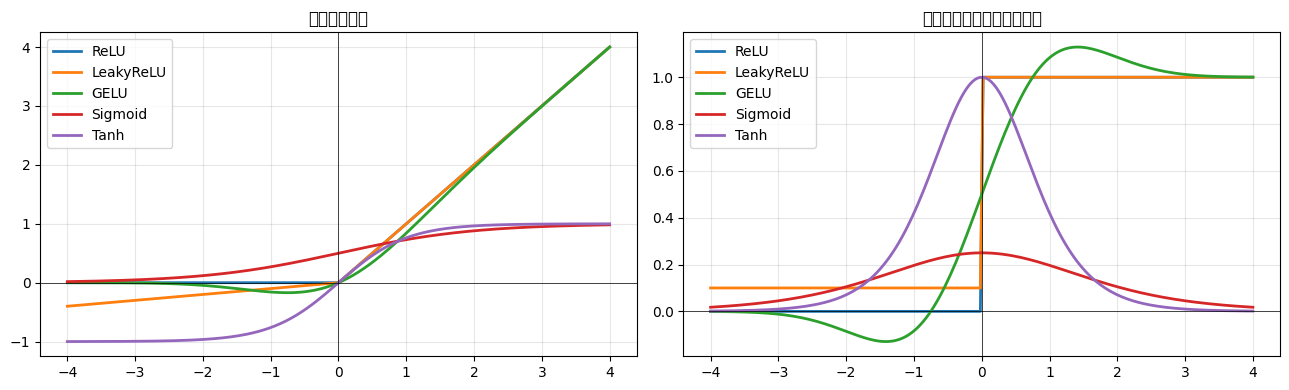


二、Dropout：train 模式 vs eval 模式

train 模式（p=0.5，随机丢弃）:
  run 1: [2 2 2 2 0 2 0 0 2 2]  (保留 7/10 个神经元)
  run 2: [2 2 0 0 2 0 2 0 0 2]  (保留 5/10 个神经元)
  run 3: [2 0 2 2 2 2 0 2 2 2]  (保留 8/10 个神经元)

eval 模式（全部保留，无随机性）:
  [1 1 1 1 1 1 1 1 1 1]
  注意：train 模式下输出已除以 (1-p) 保证期望不变

三、BatchNorm1d：归一化效果演示

原始激活值统计（batch=8, features=4）:
  均值: [6.94 1.58 7.37 4.37]
  方差: [ 92.67 173.61  34.93 137.08]

BatchNorm 后统计:
  均值: [0. 0. 0. 0.]
  方差: [1.1429 1.1429 1.1429 1.1429]

✓ BN 将每个 feature 的均值归到 ≈0，方差归到 ≈1，激活函数工作在梯度最大区间


In [9]:
# 🔬 Micro Practice: 常用层行为演示
# Goal: 直观感受激活函数、Dropout、BatchNorm 的实际效果
# Expected outcome: 理解各层在 train/eval 模式下的差异

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

print("=" * 60)
print("一、激活函数输出形状对比")
print("=" * 60)

x = torch.linspace(-3, 3, 7)
print(f"\n输入 x = {x.numpy().round(2)}\n")

acts = {
    "ReLU":        nn.ReLU(),
    "LeakyReLU":   nn.LeakyReLU(0.1),
    "GELU":        nn.GELU(),
    "Sigmoid":     nn.Sigmoid(),
    "Tanh":        nn.Tanh(),
}
for name, act in acts.items():
    out = act(x).detach().numpy().round(3)
    print(f"  {name:<12}: {out}")

# 可视化激活函数
x_plot = torch.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, act in acts.items():
    axes[0].plot(x_plot.numpy(), act(x_plot).detach().numpy(), label=name, linewidth=2)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(0, color='k', linewidth=0.5)
axes[0].set_title("激活函数输出"); axes[0].legend(); axes[0].grid(alpha=0.3)

# 激活函数导数（梯度）
for name, act in acts.items():
    xg = x_plot.clone().requires_grad_(True)
    y  = act(xg).sum(); y.backward()
    axes[1].plot(x_plot.numpy(), xg.grad.numpy(), label=name, linewidth=2)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(0, color='k', linewidth=0.5)
axes[1].set_title("激活函数导数（梯度大小）"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("二、Dropout：train 模式 vs eval 模式")
print("=" * 60)

dropout = nn.Dropout(p=0.5)
x_test  = torch.ones(10)

# train 模式：随机丢弃
dropout.train()
print(f"\ntrain 模式（p=0.5，随机丢弃）:")
for i in range(3):
    out = dropout(x_test)
    active = (out != 0).sum().item()
    print(f"  run {i+1}: {out.numpy().astype(int)}  (保留 {active}/10 个神经元)")

# eval 模式：全部保留
dropout.eval()
out_eval = dropout(x_test)
print(f"\neval 模式（全部保留，无随机性）:")
print(f"  {out_eval.numpy().astype(int)}")
print(f"  注意：train 模式下输出已除以 (1-p) 保证期望不变")

print("\n" + "=" * 60)
print("三、BatchNorm1d：归一化效果演示")
print("=" * 60)

# 模拟一个激活值分布很极端的 batch
torch.manual_seed(0)
x_raw = torch.randn(8, 4) * 10 + 5   # 均值≈5, 方差≈100
bn    = nn.BatchNorm1d(4)

bn.train()
x_normed = bn(x_raw)

print(f"\n原始激活值统计（batch=8, features=4）:")
print(f"  均值: {x_raw.mean(dim=0).detach().numpy().round(2)}")
print(f"  方差: {x_raw.var(dim=0).detach().numpy().round(2)}")
print(f"\nBatchNorm 后统计:")
print(f"  均值: {x_normed.mean(dim=0).detach().numpy().round(4)}")
print(f"  方差: {x_normed.var(dim=0).detach().numpy().round(4)}")
print(f"\n✓ BN 将每个 feature 的均值归到 ≈0，方差归到 ≈1，激活函数工作在梯度最大区间")

In [10]:
# 🔬 Micro Practice: 参数管理与权重初始化
# Goal: 掌握参数检查、冻结、初始化、保存/加载
# Expected outcome: 能够精确控制模型的哪些参数参与训练

import torch
import torch.nn as nn
import os

torch.manual_seed(42)

# ── 定义一个稍复杂的模型 ──────────────────────────────────
class TwoBlockNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
        )
        self.head = nn.Linear(8, 2)

    def forward(self, x):
        return self.head(self.encoder(x))

model = TwoBlockNet()

print("=" * 60)
print("一、参数检查")
print("=" * 60)

total, trainable = 0, 0
print(f"\n{'层名':<30} {'形状':<20} {'参数量':>8} {'可训练':>6}")
print("-" * 68)
for name, param in model.named_parameters():
    n = param.numel()
    total += n
    if param.requires_grad:
        trainable += n
    print(f"  {name:<28} {str(tuple(param.shape)):<20} {n:>8,} {str(param.requires_grad):>6}")

print("-" * 68)
print(f"  {'总参数量':<28} {total:>29,}")
print(f"  {'可训练参数量':<28} {trainable:>29,}")

print("\n" + "=" * 60)
print("二、参数冻结（迁移学习场景）")
print("=" * 60)

# 冻结 encoder，只训练 head（常见于微调预训练模型）
for param in model.encoder.parameters():
    param.requires_grad = False

frozen, active = 0, 0
for name, param in model.named_parameters():
    if param.requires_grad:
        active += param.numel()
        status = "✓ 可训练"
    else:
        frozen += param.numel()
        status = "✗ 已冻结"
    print(f"  {name:<30}: {status}")

print(f"\n  已冻结参数: {frozen:,}")
print(f"  可训练参数: {active:,}  ← 只有 head 的参数")

# 恢复所有参数可训练
for param in model.parameters():
    param.requires_grad = True

print("\n" + "=" * 60)
print("三、权重初始化对比")
print("=" * 60)

def measure_stats(model):
    """统计所有 Linear 层权重的均值和方差"""
    stats = []
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            w = m.weight.data
            stats.append((name, w.mean().item(), w.std().item()))
    return stats

# 默认初始化（PyTorch 使用 Kaiming 均匀）
model_default = TwoBlockNet()

# Kaiming 正态初始化（适合 ReLU）
model_kaiming = TwoBlockNet()
def kaiming_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)
model_kaiming.apply(kaiming_init)

# Xavier 正态初始化（适合 Sigmoid / Tanh）
model_xavier = TwoBlockNet()
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
model_xavier.apply(xavier_init)

print(f"\n{'层名':<25} {'初始化方式':<18} {'均值':>8} {'标准差':>8}")
print("-" * 62)
for init_name, mdl in [("Default (Kaiming均匀)", model_default),
                        ("Kaiming 正态",          model_kaiming),
                        ("Xavier 正态",            model_xavier)]:
    for layer_name, mean, std in measure_stats(mdl):
        print(f"  {layer_name:<23} {init_name:<18} {mean:>8.4f} {std:>8.4f}")
    print()

print("=" * 60)
print("四、模型保存与加载")
print("=" * 60)

save_path = "/tmp/demo_model.pth"

# 保存
torch.save(model.state_dict(), save_path)
print(f"\n已保存到: {save_path}  ({os.path.getsize(save_path):,} bytes)")

# 加载
model_loaded = TwoBlockNet()
model_loaded.load_state_dict(torch.load(save_path, weights_only=True))
model_loaded.eval()

# 验证参数一致
x_demo = torch.randn(1, 4)
with torch.no_grad():
    out_orig   = model(x_demo)
    out_loaded = model_loaded(x_demo)
diff = (out_orig - out_loaded).abs().max().item()
print(f"原始模型输出:   {out_orig.numpy().round(4)}")
print(f"加载模型输出:   {out_loaded.numpy().round(4)}")
print(f"最大差异: {diff:.2e}  ← 误差为 0，参数完全一致")
print(f"\n✓ 参数管理与权重初始化演示完毕")

一、参数检查

层名                             形状                        参数量    可训练
--------------------------------------------------------------------
  encoder.0.weight             (8, 4)                     32   True
  encoder.0.bias               (8,)                        8   True
  encoder.2.weight             (8, 8)                     64   True
  encoder.2.bias               (8,)                        8   True
  head.weight                  (2, 8)                     16   True
  head.bias                    (2,)                        2   True
--------------------------------------------------------------------
  总参数量                                                   130
  可训练参数量                                                 130

二、参数冻结（迁移学习场景）
  encoder.0.weight              : ✗ 已冻结
  encoder.0.bias                : ✗ 已冻结
  encoder.2.weight              : ✗ 已冻结
  encoder.2.bias                : ✗ 已冻结
  head.weight                   : ✓ 可训练
  head.bias                     : ✓ 可训练


### 3.4 训练循环 (Training Loop)

训练循环是神经网络学习的核心引擎。每一轮迭代，模型都在"犯错 → 得到反馈 → 纠正"，循环往复，直到损失收敛。

---

#### 3.4.1 完整训练流程总览

```
┌─────────────────────────────────────────────────────────┐
│                     训练循环（每个 Epoch）                 │
│                                                         │
│  ① 准备数据  →  ② 前向传播  →  ③ 计算损失               │
│       ↑                              ↓                  │
│  ⑦ 评估验证  ←  ⑥ 更新参数  ←  ④ 清零梯度              │
│                       ↑                                 │
│                  ⑤ 反向传播                             │
└─────────────────────────────────────────────────────────┘
```

---

#### 3.4.2 各步骤详细说明

**① 数据准备（Data Preparation）**

将原始数据封装为 `Dataset` 和 `DataLoader`，实现批量加载、随机打乱、多进程预处理：

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)
loader  = DataLoader(dataset, batch_size=32, shuffle=True)
```

- `batch_size`：每次送入网络的样本数，影响梯度估计的噪声程度
- `shuffle=True`：每个 epoch 随机打乱，避免模型记住顺序

---

**② 前向传播（Forward Pass）**

将一批数据输入模型，得到预测值：

```python
model.train()          # 切换到训练模式（激活 Dropout / BN）
outputs = model(X)     # 内部调用 model.forward(X)
```

> 必须在前向传播之前调用 `model.train()`，确保 Dropout、BatchNorm 等层行为正确。

---

**③ 计算损失（Compute Loss）**

选择与任务匹配的损失函数，量化预测与真实值的差距：

```python
loss = criterion(outputs, y)   # criterion 是提前定义的损失函数
```

损失函数选择原则（见下方组件介绍）。

---

**④ 清零梯度（Zero Gradients）**

**每次反向传播前必须清零**，PyTorch 默认累积梯度：

```python
optimizer.zero_grad()   # 清除上一批次遗留的梯度
```

> 如不清零，梯度会在多次迭代间叠加，导致参数更新量越来越大，训练发散。

---

**⑤ 反向传播（Backward Pass）**

从损失出发，沿计算图逆向传播，自动计算所有参数的梯度：

```python
loss.backward()   # 触发 autograd，填充所有 param.grad
```

> `backward()` 之后可通过 `param.grad` 查看任意参数的梯度，便于调试。

---

**⑥ 参数更新（Optimizer Step）**

优化器读取各参数的 `.grad`，按优化算法规则更新权重：

```python
optimizer.step()   # W = W - lr * W.grad（以 SGD 为例）
```

---

**⑦ 评估验证（Evaluation）**

每隔若干 epoch 在验证集上评估，监控泛化性能、检测过拟合：

```python
model.eval()                   # 关闭 Dropout，BN 使用运行统计量
with torch.no_grad():          # 禁用梯度计算，节省内存
    val_outputs = model(X_val)
    val_loss = criterion(val_outputs, y_val)
```

> `model.eval()` + `torch.no_grad()` 是评估阶段的固定搭配，缺一不可。

---

#### 3.4.3 关键组件详解

---

**▶ 损失函数（Loss Function）**

损失函数衡量预测值与真实值的差距，是梯度的来源。

| 损失函数 | API | 适用场景 | 输出层激活 |
|----------|-----|----------|-----------|
| 均方误差（MSE） | `nn.MSELoss()` | 回归任务 | 无（线性输出） |
| 二元交叉熵 | `nn.BCELoss()` | 二分类（单标签） | `Sigmoid` |
| BCE with Logits | `nn.BCEWithLogitsLoss()` | 二分类（数值稳定） | **无**（内置 Sigmoid） |
| 交叉熵 | `nn.CrossEntropyLoss()` | 多分类 | **无**（内置 Softmax） |
| 负对数似然 | `nn.NLLLoss()` | 多分类 | `LogSoftmax` |

> **推荐**：多分类任务用 `CrossEntropyLoss`（不要在输出层加 Softmax）；二分类用 `BCEWithLogitsLoss`（不要在输出层加 Sigmoid），数值更稳定。

---

**▶ 优化器（Optimizer）**

优化器决定如何利用梯度更新参数，直接影响收敛速度和最终精度。

| 优化器 | API | 特点 | 推荐学习率 |
|--------|-----|------|-----------|
| 随机梯度下降 | `optim.SGD(lr, momentum)` | 简单，泛化好，需调参 | 0.01–0.1 |
| Adam | `optim.Adam(lr)` | 自适应学习率，收敛快 | 1e-3 |
| AdamW | `optim.AdamW(lr, weight_decay)` | Adam + 正确的权重衰减 | 1e-3 |
| RMSProp | `optim.RMSprop(lr)` | 适合 RNN/非平稳目标 | 1e-3 |

**SGD vs Adam 选择建议**：
- 快速实验 / NLP：优先用 `Adam` 或 `AdamW`
- CV 精度优先：`SGD + momentum=0.9 + 余弦学习率衰减` 往往能取得更高精度

---

**▶ 学习率调度器（LR Scheduler）**

固定学习率通常不是最优策略，动态调整学习率可加速收敛并提升最终性能：

| 调度器 | API | 策略 |
|--------|-----|------|
| 步进衰减 | `StepLR(optimizer, step_size, gamma)` | 每 N 步乘以 gamma |
| 余弦退火 | `CosineAnnealingLR(optimizer, T_max)` | 按余弦曲线衰减到最小 lr |
| 预热 + 衰减 | `OneCycleLR` | 先升后降，Transformer 常用 |

```python
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
# 训练循环中每个 epoch 末尾调用：
scheduler.step()
```

---

**▶ model.train() 与 model.eval()**

| 调用 | Dropout | BatchNorm | 适用阶段 |
|------|---------|-----------|---------|
| `model.train()` | 按概率随机丢弃 | 用当前 batch 统计量 | 训练时 |
| `model.eval()` | 关闭（全部保留） | 用训练期积累的运行均值/方差 | 验证/测试/推理时 |

---

**▶ torch.no_grad() 与 .detach()**

| 工具 | 作用范围 | 内存节省 | 典型用途 |
|------|---------|---------|---------|
| `torch.no_grad()` | 上下文块内所有操作 | 是（不存中间激活） | 验证/推理 |
| `.detach()` | 单个 tensor | 否（共享数据） | 截断梯度流（GAN、目标网络） |

In [5]:
# 🔬 Micro Practice: Complete Training Loop
# Goal: Train neural network on XOR problem
# Expected outcome: Successfully learn XOR function

# Prepare data
X_train = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)
y_train = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)

print("Training data (XOR):")
for x, y in zip(X_train, y_train):
    print(f"  Input: {x.numpy()}, Target: {y.item()}")
print()

# Create model
model = SimpleNN(input_size=2, hidden_size=8, output_size=1)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)

# Training loop
num_epochs = 5000
losses = []

print("Training...")
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass and optimization
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update parameters
    
    # Record loss
    losses.append(loss.item())
    
    # Print progress
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}")

print("\nTraining completed!")
print()

# Test the model
print("Final predictions:")
with torch.no_grad():  # Disable gradient computation for inference
    predictions = model(X_train)
    for x, y_true, y_pred in zip(X_train, y_train, predictions):
        print(f"Input: {x.numpy()}, True: {y_true.item()}, "
              f"Pred: {y_pred.item():.4f}, Rounded: {round(y_pred.item())}")

print("\n✓ Model successfully learned XOR function!")

Training data (XOR):
  Input: [0. 0.], Target: 0.0
  Input: [0. 1.], Target: 1.0
  Input: [1. 0.], Target: 1.0
  Input: [1. 1.], Target: 0.0

Training...
Epoch [1000/5000], Loss: 0.000672
Epoch [2000/5000], Loss: 0.000269
Epoch [3000/5000], Loss: 0.000162
Epoch [4000/5000], Loss: 0.000114
Epoch [5000/5000], Loss: 0.000087

Training completed!

Final predictions:
Input: [0. 0.], True: 0.0, Pred: 0.0115, Rounded: 0
Input: [0. 1.], True: 1.0, Pred: 0.9914, Rounded: 1
Input: [1. 0.], True: 1.0, Pred: 0.9915, Rounded: 1
Input: [1. 1.], True: 0.0, Pred: 0.0084, Rounded: 0

✓ Model successfully learned XOR function!


In [ ]:
# 🔬 Micro Practice: 关键组件对比 —— 损失函数与优化器
# Goal: 直观理解不同损失函数的适用场景，以及优化器的收敛差异
# Expected outcome: 掌握组件选型的原则

import torch
import torch.nn as nn
import torch.optim as optim

print("=" * 60)
print("一、常用损失函数对比")
print("=" * 60)

# ── MSELoss：回归 ──────────────────────────────────────────
pred_reg  = torch.tensor([2.5, 0.8, 1.9])
label_reg = torch.tensor([3.0, 1.0, 2.0])
mse = nn.MSELoss()(pred_reg, label_reg)
print(f"\n① MSELoss（回归）")
print(f"   pred={pred_reg.numpy()}  label={label_reg.numpy()}")
print(f"   MSE = {mse.item():.6f}")

# ── BCEWithLogitsLoss：二分类（推荐，数值稳定）─────────────
logits_bin  = torch.tensor([2.0, -1.0, 0.5, -0.3])   # 原始 logits（不过 Sigmoid）
labels_bin  = torch.tensor([1.0,  0.0, 1.0,  0.0])
bce_logits  = nn.BCEWithLogitsLoss()(logits_bin, labels_bin)
# 等价的不稳定写法（不推荐）
bce_naive   = nn.BCELoss()(torch.sigmoid(logits_bin), labels_bin)
print(f"\n② BCEWithLogitsLoss vs BCELoss（二分类）")
print(f"   logits = {logits_bin.numpy()}")
print(f"   BCEWithLogitsLoss = {bce_logits.item():.6f}  ← 推荐，内置 Sigmoid，数值更稳定")
print(f"   BCELoss (手动sigmoid) = {bce_naive.item():.6f}  ← 结果相同，但可能有数值精度问题")

# ── CrossEntropyLoss：多分类 ───────────────────────────────
logits_mc  = torch.tensor([[2.0, 1.0, 0.1],   # 样本1 的 logits
                            [0.5, 2.5, 0.3]])   # 样本2 的 logits
labels_mc  = torch.tensor([0, 1])              # 真实类别索引（不是 one-hot）
ce_loss    = nn.CrossEntropyLoss()(logits_mc, labels_mc)
print(f"\n③ CrossEntropyLoss（多分类）")
print(f"   logits shape = {logits_mc.shape}  (batch=2, classes=3)")
print(f"   true labels = {labels_mc.numpy()}  (类别索引，不是 one-hot)")
print(f"   CrossEntropyLoss = {ce_loss.item():.6f}")
print(f"   注意：输出层不要加 Softmax，CrossEntropyLoss 内部已包含")

print("\n" + "=" * 60)
print("二、优化器收敛速度对比（在简单回归任务上）")
print("=" * 60)

# 简单任务：拟合 y = 2x + 1
torch.manual_seed(42)
X = torch.linspace(-1, 1, 50).unsqueeze(1)
y = 2 * X + 1 + 0.1 * torch.randn_like(X)

def make_model():
    """每次从相同初始化开始，公平对比"""
    torch.manual_seed(0)
    return nn.Linear(1, 1)

def train_with_optimizer(opt_name, optimizer_fn, epochs=300):
    model = make_model()
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.MSELoss()
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

configs = {
    "SGD (lr=0.1)":          lambda p: optim.SGD(p, lr=0.1),
    "SGD+Momentum (lr=0.1)": lambda p: optim.SGD(p, lr=0.1, momentum=0.9),
    "Adam (lr=0.01)":        lambda p: optim.Adam(p, lr=0.01),
    "AdamW (lr=0.01)":       lambda p: optim.AdamW(p, lr=0.01, weight_decay=1e-3),
}

results = {}
for name, opt_fn in configs.items():
    losses = train_with_optimizer(name, opt_fn, epochs=200)
    results[name] = losses
    print(f"   {name:<28} → 最终 loss: {losses[-1]:.6f}")

# 可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
for name, losses in results.items():
    plt.plot(losses, label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("不同优化器的收敛曲线对比")
plt.legend()
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Adam 系列收敛更快，SGD+Momentum 在简单任务上也表现良好")

In [ ]:
# 🔬 Micro Practice: 带 DataLoader + 验证集 + LR Scheduler 的完整训练循环
# Goal: 实现工业级训练循环模板
# Expected outcome: 掌握完整规范的 PyTorch 训练流程

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ── ① 数据准备 ─────────────────────────────────────────────
print("① 数据准备")
X_np, y_np = make_moons(n_samples=800, noise=0.2, random_state=42)

# 划分训练集 / 验证集（7:3）
split = int(0.7 * len(X_np))
X_train, X_val = X_np[:split], X_np[split:]
y_train, y_val = y_np[:split], y_np[split:]

# 转为 Tensor
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1)

# 封装为 DataLoader（自动 batch + shuffle）
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=64, shuffle=False)

print(f"   训练集: {X_train_t.shape[0]} 样本，{len(train_loader)} 个 batch")
print(f"   验证集: {X_val_t.shape[0]} 样本，{len(val_loader)} 个 batch")

# ── ② 模型定义 ────────────────────────────────────────────
print("\n② 模型定义")

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
            # 注意：不加 Sigmoid，使用 BCEWithLogitsLoss
        )
    def forward(self, x):
        return self.net(x)

model     = MLP()
criterion = nn.BCEWithLogitsLoss()              # 内置 Sigmoid，数值更稳定
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-4)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   模型参数量: {total_params}")
print(f"   损失函数: BCEWithLogitsLoss（二分类，内置 Sigmoid）")
print(f"   优化器: Adam, lr=0.01")
print(f"   学习率调度: CosineAnnealingLR（余弦退火）")

# ── ③ 完整训练循环 ────────────────────────────────────────
print("\n③ 开始训练")
print("-" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val Acc':>8} | {'LR':>10}")
print("-" * 65)

train_losses, val_losses, val_accs, lrs = [], [], [], []

EPOCHS = 60

for epoch in range(1, EPOCHS + 1):

    # ── 训练阶段 ──────────────────────────────────────────
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()          # ④ 清零梯度
        logits = model(X_batch)        # ② 前向传播
        loss   = criterion(logits, y_batch)  # ③ 计算损失
        loss.backward()                # ⑤ 反向传播
        optimizer.step()               # ⑥ 参数更新
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # ── 验证阶段 ──────────────────────────────────────────
    model.eval()
    val_batch_losses, correct, total = [], 0, 0
    with torch.no_grad():              # 禁用梯度计算
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_batch_losses.append(loss.item())
            preds   = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)

    val_loss = np.mean(val_batch_losses)
    val_acc  = correct / total
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    lrs.append(current_lr)

    scheduler.step()    # ⑦ 更新学习率

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>8.4f} | {val_acc:>7.2%} | {current_lr:>10.6f}")

print("-" * 65)
print(f"\n   最终验证准确率: {val_accs[-1]:.2%}")
print(f"   最佳验证准确率: {max(val_accs):.2%} (epoch {val_accs.index(max(val_accs))+1})")

# ── 可视化 ────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('训练 vs 验证损失'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 验证准确率
axes[1].plot(val_accs, color='green', linewidth=2)
axes[1].axhline(max(val_accs), color='red', linestyle=':', label=f'Best: {max(val_accs):.2%}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('验证准确率'); axes[1].legend(); axes[1].grid(alpha=0.3)

# 学习率曲线
axes[2].plot(lrs, color='orange', linewidth=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('余弦退火学习率'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ 完整训练循环演示完毕（DataLoader + 验证集 + LR Scheduler）")

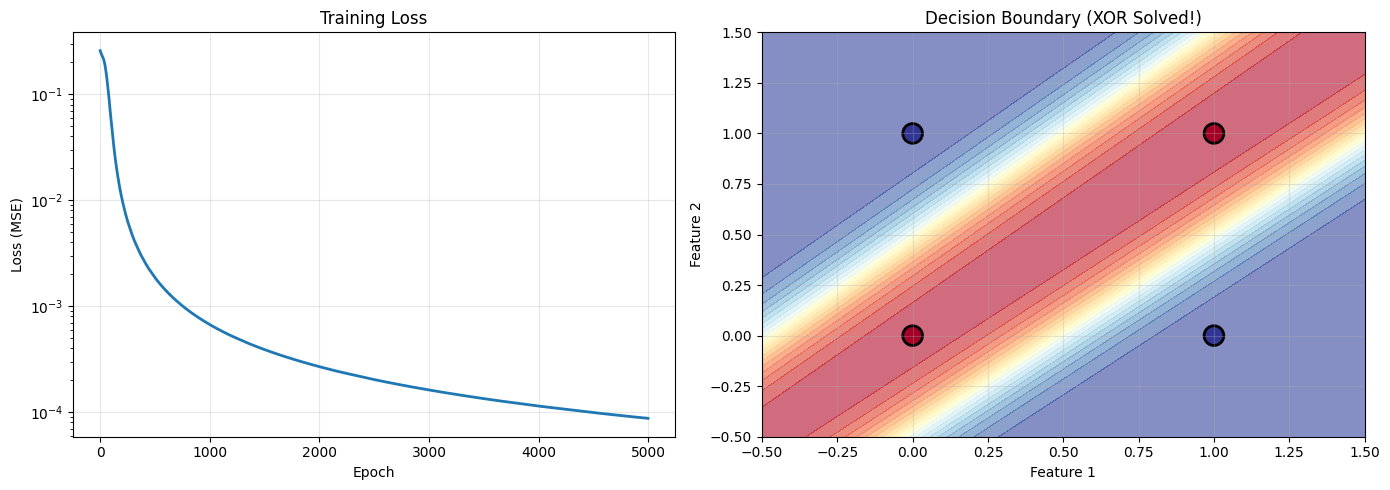

✓ PyTorch successfully trained the model!


In [6]:
# 🔬 Micro Practice: Visualize Training Progress
# Goal: See loss curve and decision boundary

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(losses, linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on grid
with torch.no_grad():
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model(grid_tensor).numpy()
    Z = Z.reshape(xx.shape)

ax2.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
ax2.scatter(X_train[:, 0], X_train[:, 1], c=y_train.numpy().ravel(),
           cmap='RdYlBu', s=200, edgecolors='black', linewidth=2)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_title('Decision Boundary (XOR Solved!)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ PyTorch successfully trained the model!")

## 6. 综合项目：完整的分类任务

### 项目目标

使用PyTorch实现一个完整的二分类任务，包括：
- 数据准备
- 模型定义
- 训练循环
- 评估和可视化

In [7]:
# 🚀 Capstone Project: Binary Classification
# Goal: Complete end-to-end PyTorch workflow
# Expected outcome: Working classification pipeline

# Generate synthetic dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Create dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

print(f"Training set: {X_train_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}\n")

# Define model
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize
model = Classifier()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training
epochs = 1000
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_tensor)
    train_loss = criterion(train_pred, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)
        test_loss = criterion(test_pred, y_test_tensor)
        test_losses.append(test_loss.item())
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

# Final evaluation
model.eval()
with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_pred_class = (test_pred > 0.5).float()
    accuracy = (test_pred_class == y_test_tensor).float().mean()
    print(f"\nTest Accuracy: {accuracy.item():.2%}")

print("\n✓ Capstone project completed!")

Training set: torch.Size([800, 2])
Test set: torch.Size([200, 2])

Epoch 200/1000, Train Loss: 0.1401, Test Loss: 0.1247
Epoch 400/1000, Train Loss: 0.0877, Test Loss: 0.0769
Epoch 600/1000, Train Loss: 0.0726, Test Loss: 0.0637
Epoch 800/1000, Train Loss: 0.0662, Test Loss: 0.0563
Epoch 1000/1000, Train Loss: 0.0626, Test Loss: 0.0508

Test Accuracy: 98.00%

✓ Capstone project completed!


## 7. 常见问题与调试

### Q1: 什么时候使用.detach()或torch.no_grad()？

**A:**
- `torch.no_grad()`: 推理时，不需要计算梯度
- `.detach()`: 从计算图中分离tensor

### Q2: 为什么要调用optimizer.zero_grad()？

**A:** PyTorch默认累积梯度。每次迭代前需要清零，否则梯度会叠加。

### Q3: model.train()和model.eval()有什么区别？

**A:**
- `model.train()`: 训练模式（Dropout、BatchNorm等会生效）
- `model.eval()`: 评估模式（Dropout关闭、BatchNorm使用统计值）

## 8. 总结与展望

### 核心要点

1. **Tensor**: PyTorch的核心数据结构
2. **Autograd**: 自动微分，无需手动推导梯度
3. **nn.Module**: 构建模型的标准方式
4. **训练循环**: 前向→损失→反向→更新

### Module 1 完成！

恭喜！你已经完成了Module 1的所有内容：
- ✅ 数学基础
- ✅ 神经网络原理
- ✅ 反向传播算法
- ✅ PyTorch实践

### 下一步：Module 2 - 从RNN到Attention

准备学习序列模型和注意力机制！

## 9. 思考题参考答案

### 问题 1：PyTorch 的动态计算图与静态计算图（如 TensorFlow 1.x）有什么区别？各有什么优缺点？

**静态计算图（Define-and-Run）**：

在 TensorFlow 1.x 中，计算图在运行之前必须先完整定义，然后通过 `Session.run()` 执行：

```
# 先定义图结构（不执行）
x = tf.placeholder(tf.float32)
y = x * 2 + 1
# 再执行
with tf.Session() as sess:
    result = sess.run(y, feed_dict={x: 3.0})
```

**动态计算图（Define-by-Run）**：

PyTorch 在每次前向传播时**实时构建**计算图，代码执行即图构建：

```python
x = torch.tensor(3.0, requires_grad=True)
y = x * 2 + 1  # 图随执行动态创建
y.backward()
```

**对比总结**：

| 维度 | 静态计算图 | 动态计算图（PyTorch） |
|------|-----------|---------------------|
| 调试难度 | 难，错误在运行时才暴露 | 易，可直接用 Python 调试器 |
| 灵活性 | 低，图结构固定 | 高，支持条件分支、循环等动态结构 |
| 性能优化 | 强，编译器可全局优化 | 较弱（但 `torch.compile` 正在弥补） |
| 适合场景 | 生产部署、推理加速 | 研究、实验、复杂模型开发 |
| 序列建模 | 需要 dynamic_rnn 等额外机制 | 自然支持变长序列 |

**PyTorch 的 `torch.compile`**（PyTorch 2.0+）通过 JIT 编译实现了动态图的性能接近静态图，是目前最佳实践。

---

### 问题 2：为什么每次反向传播前需要调用 `optimizer.zero_grad()`？如果不调用会发生什么？

**根本原因：PyTorch 的梯度累积机制**

PyTorch 在调用 `.backward()` 时，会将计算出的梯度**累加**到 `.grad` 属性上，而不是覆盖：

```python
x = torch.tensor(2.0, requires_grad=True)

# 第1次反向传播
loss1 = x ** 2
loss1.backward()
print(x.grad)  # 输出: 4.0 (即 2x = 4)

# 第2次反向传播（未清零）
loss2 = x ** 2
loss2.backward()
print(x.grad)  # 输出: 8.0 (累积了两次梯度！)
```

**不调用 `zero_grad()` 的后果**：

梯度会在每次迭代中累积，导致参数更新量越来越大，训练不稳定甚至发散：

$$\theta_{t+1} = \theta_t - \alpha \cdot \underbrace{\sum_{k=1}^{t} \nabla L_k}_{\text{累积梯度（错误）}}$$

正确做法是每次迭代只使用当前 batch 的梯度：

$$\theta_{t+1} = \theta_t - \alpha \cdot \nabla L_t$$

**梯度累积的合理使用场景**：

有时**故意**利用梯度累积来模拟更大的 batch size（当 GPU 显存不足时）：

```python
accumulation_steps = 4
for i, (x, y) in enumerate(dataloader):
    loss = criterion(model(x), y) / accumulation_steps
    loss.backward()  # 累积梯度
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()   # 每4步更新一次
        optimizer.zero_grad()
```

---

### 问题 3：`model.train()` 和 `model.eval()` 的区别是什么？哪些层受到影响？

**行为差异**：

这两个方法切换模型的运行模式，影响特定层的计算行为：

**受影响的层**：

| 层类型 | `model.train()` 模式 | `model.eval()` 模式 |
|--------|---------------------|---------------------|
| `nn.Dropout` | 随机丢弃神经元（按概率 $p$） | 关闭 Dropout，所有神经元参与计算 |
| `nn.BatchNorm1d/2d` | 使用当前 batch 的均值/方差归一化 | 使用训练期间积累的**运行均值/方差** |
| `nn.Linear`、`nn.Conv2d` 等 | 无差异 | 无差异 |

**为什么 Dropout 在推理时要关闭？**

训练时 Dropout 以概率 $p$ 丢弃神经元，为了保持期望输出不变，输出会乘以 $\frac{1}{1-p}$。推理时若保持 Dropout，每次推理结果不同（随机性），且期望已正确缩放，故关闭 Dropout 保证确定性输出。

**为什么 BatchNorm 在推理时用运行统计量？**

推理时可能只有单个样本（batch size=1），无法计算 batch 统计量。使用训练期间用指数移动平均积累的全局统计量，保证推理的稳定性。

**常见错误示范**：

```python
# 错误：评估时忘记切换模式
model.train()  # 保持训练模式
with torch.no_grad():
    preds = model(test_data)  # Dropout 仍然激活！结果不稳定

# 正确做法
model.eval()
with torch.no_grad():
    preds = model(test_data)
```

---

### 问题 4：`torch.no_grad()` 和 `.detach()` 分别在什么情况下使用？有什么本质区别？

**`torch.no_grad()` —— 上下文管理器**

在推理或评估时，禁用整个代码块内的梯度计算，节省内存和计算资源：

```python
model.eval()
with torch.no_grad():
    # 这个代码块内的所有操作都不追踪梯度
    predictions = model(X_test)
    loss = criterion(predictions, y_test)
# 块外恢复正常梯度追踪
```

**`.detach()` —— 从计算图中分离 Tensor**

创建一个与原 tensor 共享数据但不参与梯度计算的新 tensor：

```python
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

# detach 创建新 tensor，不在计算图中
y_detached = y.detach()
print(y_detached.requires_grad)  # False
# 对 y_detached 的操作不会影响 x 的梯度
```

**本质区别与使用场景**：

| 特性 | `torch.no_grad()` | `.detach()` |
|------|------------------|-------------|
| 作用范围 | 上下文块内所有操作 | 单个 tensor |
| 内存节省 | 节省（不存储中间激活值） | 共享内存，不额外节省 |
| 典型用途 | 推理、验证集评估 | 停止梯度流动到特定路径 |
| GAN 训练 | — | 训练生成器时固定判别器权重 |
| 强化学习 | — | 固定目标网络（target network） |

**`.detach()` 的高级用途示例**：

```python
# GAN 中训练判别器时，不希望梯度流入生成器
fake_images = generator(noise)
fake_images_detached = fake_images.detach()  # 截断梯度
d_loss = criterion(discriminator(fake_images_detached), fake_labels)
d_loss.backward()  # 只更新判别器参数
```

---

### 问题 5：Adam 优化器相比 SGD 有什么优势？在什么情况下 SGD 可能更好？

**Adam 的核心机制**：

Adam（Adaptive Moment Estimation）结合了动量（Momentum）和自适应学习率（RMSProp）：

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{（一阶矩：梯度的指数移动平均）}$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{（二阶矩：梯度平方的指数移动平均）}$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{（偏差修正）}$$

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t \quad \text{（参数更新）}$$

**Adam vs SGD 对比**：

| 维度 | Adam | SGD（带动量） |
|------|------|-------------|
| 学习率调整 | 每个参数自适应 | 所有参数统一 |
| 收敛速度 | 快，对超参数不敏感 | 慢，需要精心调参 |
| 稀疏梯度 | 表现好（适合 NLP/embedding） | 表现差 |
| 最终精度 | 有时次优（泛化稍弱） | 调好后往往更优 |
| 内存占用 | 更高（需存储 $m_t, v_t$） | 低 |

**SGD 更优的场景**：
- 计算机视觉任务（ResNet、VGG 等在精心调参的 SGD 下往往达到更高准确率）
- 有充足时间调参时
- 需要更好泛化性能时（Adam 存在"泛化差距"问题）

**实践建议**：
- 快速实验和 NLP 任务：优先用 Adam（`lr=1e-3`，默认参数）
- 追求最优精度的 CV 任务：考虑带余弦退火的 SGD with Momentum